<a href="https://colab.research.google.com/github/Dur-e-yashfeen/Predicting-Stellar-Class/blob/main/Predicting_Stellar_Class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1.Login Kaggle with API and download data in Dir

In [2]:
import kagglehub
# You may need to re-run this cell after logging in.
kagglehub.login()

In [3]:
path = kagglehub.competition_download('playground-series-s6e6')

100%|██████████| 58.6M/58.6M [00:00<00:00, 119MB/s]

Extracting files...


First, let's inspect the contents of the downloaded directory to see what CSV files are available. Then, we can use `pandas` to load them.

## 2.Load Important libraries

In [6]:
!{sys.executable} -m pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
import sys
import lightgbm as lgb
from xgboost import XGBClassifier
import xgboost as xgb # Added for callbacks
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic parameters for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## 3.Load Dataset from directory

In [8]:
import os
# List contents of the downloaded directory
print(f"Contents of the downloaded Kaggle competition path ({path}):")
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))


Contents of the downloaded Kaggle competition path (/root/.cache/kagglehub/competitions/playground-series-s6e6):
/root/.cache/kagglehub/competitions/playground-series-s6e6/train.csv
/root/.cache/kagglehub/competitions/playground-series-s6e6/test.csv
/root/.cache/kagglehub/competitions/playground-series-s6e6/sample_submission.csv


Now, let's assume `train.csv` and `test.csv` are present in the root of the downloaded path, which is common for Kaggle competitions. We'll load them into pandas DataFrames.

In [9]:
train_df = pd.read_csv(os.path.join(path, 'train.csv'))
test_df = pd.read_csv(os.path.join(path, 'test.csv'))
submission_df = pd.read_csv(os.path.join(path, 'sample_submission.csv'))

In [10]:
train_df.head(3)

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO


In [11]:
test_df.head(3)

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
0,577347,120.719779,23.924249,23.668066,21.951680,21.086183,20.180032,19.202124,0.429042,G/K,Red_Sequence
1,577348,219.414419,42.171651,24.902933,22.338822,20.732163,19.860330,19.687691,0.867305,M,Red_Sequence
2,577349,173.568731,-1.756400,19.427591,18.474633,17.551314,16.570674,16.176765,0.224234,G/K,Blue_Cloud


In [12]:
# let's find Shape of Dataset
print(f"✅ Training samples: {train_df.shape[0]}")
print(f"✅ Test samples: {test_df.shape[0]}")
print(f"\nColumns in dataset:\n{train_df.columns.tolist()}")

✅ Training samples: 577347
✅ Test samples: 247435

Columns in dataset:
['id', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type', 'galaxy_population', 'class']


## 4. Exploratory Data Analysis (Quick Checks)

- No missing values (typical for playground data)  
- Target: `class` has three categories  
- Features: 8 numerical magnitudes/redshift + 3 ID columns (`objid`, `plate`, `mjd`, `fiberid`) – we'll drop IDs.

### 4.1 Data Overview & Missing Values
- Playground data is clean, but it's always good practice to check.

In [13]:
# Check for missing values
print("Missing values per column (Train):")
print(train_df.isnull().sum())

Missing values per column (Train):
id                   0
alpha                0
delta                0
u                    0
g                    0
r                    0
i                    0
z                    0
redshift             0
spectral_type        0
galaxy_population    0
class                0
dtype: int64


In [14]:
# Quick statistical summary of the numerical features
display(train_df.describe())

,id,alpha,delta,u,g,r,i,z,redshift
count,577347.00000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,288673.00000,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135
std,166665.86727,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070
min,0.00000,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970
25%,144336.50000,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052
50%,288673.00000,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525
75%,433009.50000,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390
max,577346.00000,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780


### 4.2 Target Variable Distribution
- We need to ensure the classes are balanced (they usually are in this competition).

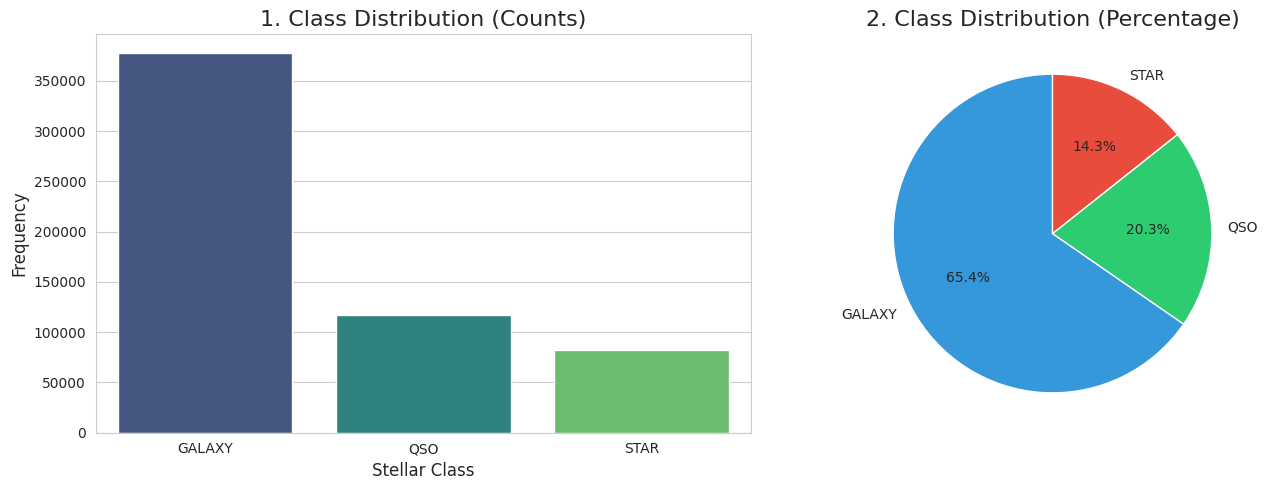

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Countplot
order = train_df['class'].value_counts().index
sns.countplot(x='class', data=train_df, palette='viridis', order=order, ax=ax[0])
ax[0].set_title('1. Class Distribution (Counts)')
ax[0].set_xlabel('Stellar Class')
ax[0].set_ylabel('Frequency')

# Pie chart
train_df['class'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['#3498db', '#2ecc71', '#e74c3c'], ax=ax[1])
ax[1].set_title('2. Class Distribution (Percentage)')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

### 4.3 The "Golden Plot" - Color-Color Diagram (u-g vs g-r)
- In astronomy, plotting the difference of magnitudes reveals distinct clusters.
- *   **Stars** lie on a narrow "Stellar Locus".
- *   **Quasars (QSO)** have very blue `u-g` colors.
- *   **Galaxies** spread out widely in the redder regions.

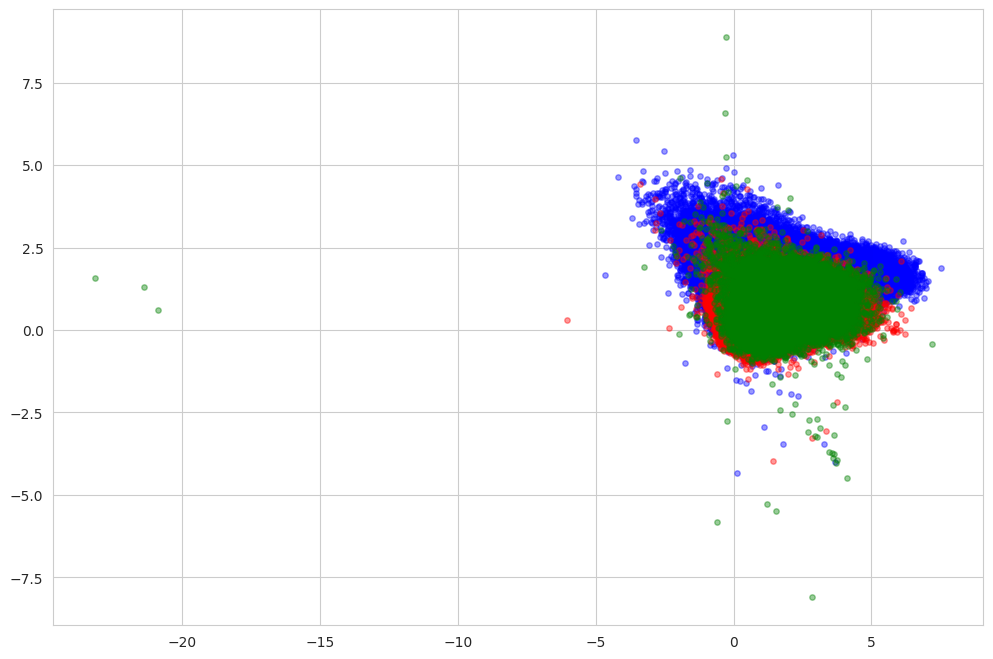

In [16]:
# Calculate raw colors for visualization
train_viz = train_df.copy()
train_viz['u_g'] = train_viz['u'] - train_viz['g']
train_viz['g_r'] = train_viz['g'] - train_viz['r']

plt.figure(figsize=(12, 8))
colors_map = {'GALAXY': 'blue', 'STAR': 'green', 'QSO': 'red'}

for cls in train_viz['class'].unique():
    subset = train_viz[train_viz['class'] == cls]
    plt.scatter(subset['u_g'], subset['g_r'],
                label=cls, alpha=0.4, s=15, color=colors_map[cls])

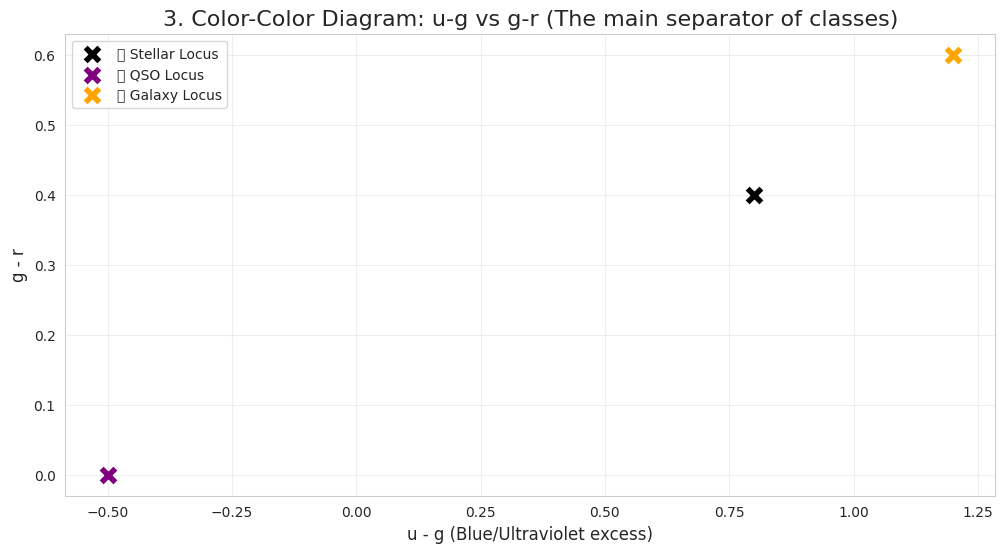

In [17]:
# Plot our "engineered locus" points to show where the model will focus
plt.scatter(0.8, 0.4, marker='X', s=200, color='black', edgecolor='white', label='✨ Stellar Locus')
plt.scatter(-0.5, 0.0, marker='X', s=200, color='purple', edgecolor='white', label='✨ QSO Locus')
plt.scatter(1.2, 0.6, marker='X', s=200, color='orange', edgecolor='white', label='✨ Galaxy Locus')

plt.title('3. Color-Color Diagram: u-g vs g-r (The main separator of classes)')
plt.xlabel('u - g (Blue/Ultraviolet excess)')
plt.ylabel('g - r')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

- **Insight:** Notice how Stars are tightly packed, QSOs are spread towards negative `u-g`, and Galaxies are spread towards positive `g-r`. Our Feature Engineering will create distances to these specific locus points.

### 4.4 Redshift Distribution (Crucial for QSOs)
- Quasars are high-redshift objects. This plot will show a long tail of high-redshift values for the QSO class.


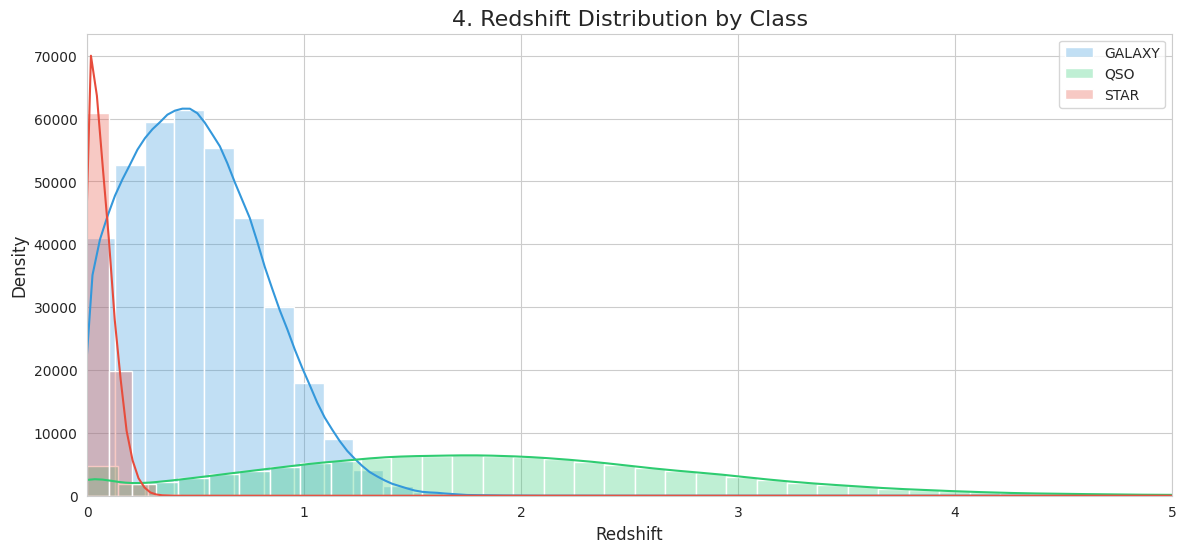

In [18]:
plt.figure(figsize=(14, 6))
for i, cls in enumerate(train_df['class'].unique()):
    subset = train_df[train_df['class'] == cls]
    sns.histplot(subset['redshift'], label=cls, kde=True, alpha=0.3,
                 color=['#3498db', '#2ecc71', '#e74c3c'][i], bins=50)
plt.title('4. Redshift Distribution by Class')
plt.xlabel('Redshift')
plt.ylabel('Density')
plt.legend()
plt.xlim(0, 5)  # Zoom in on the main distribution
plt.show()

**Insight:** We will create a `redshift_bin` categorical feature and an interaction term `redshift * (u-g)` to help the tree model split QSOs more effectively.

### 4.5 Correlation Heatmap

- Raw magnitudes (`u, g, r, i, z`) are highly correlated with each other.
- This confirms that using *differences* (color indices) removes redundancy and is better for tree-based models.

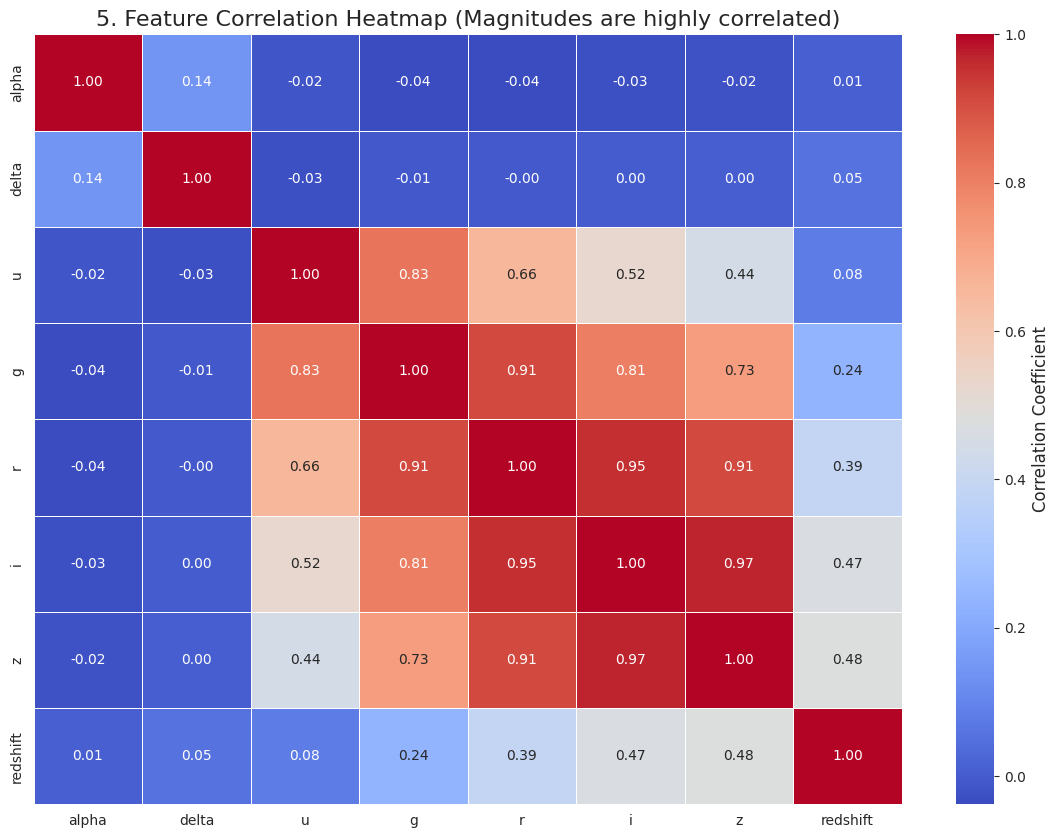

In [19]:
# Drop IDs, target, and categorical columns for correlation matrix
numeric_cols = train_df.select_dtypes(include=np.number).drop(columns=['id', 'class'], errors='ignore')
corr = numeric_cols.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('5. Feature Correlation Heatmap (Magnitudes are highly correlated)')
plt.show()

### 4.6 Outlier Check (Boxplots)
- Let's check the magnitude ranges. In SDSS, magnitudes usually range between ~14 and ~25. Extreme values might be rare objects or artifacts.

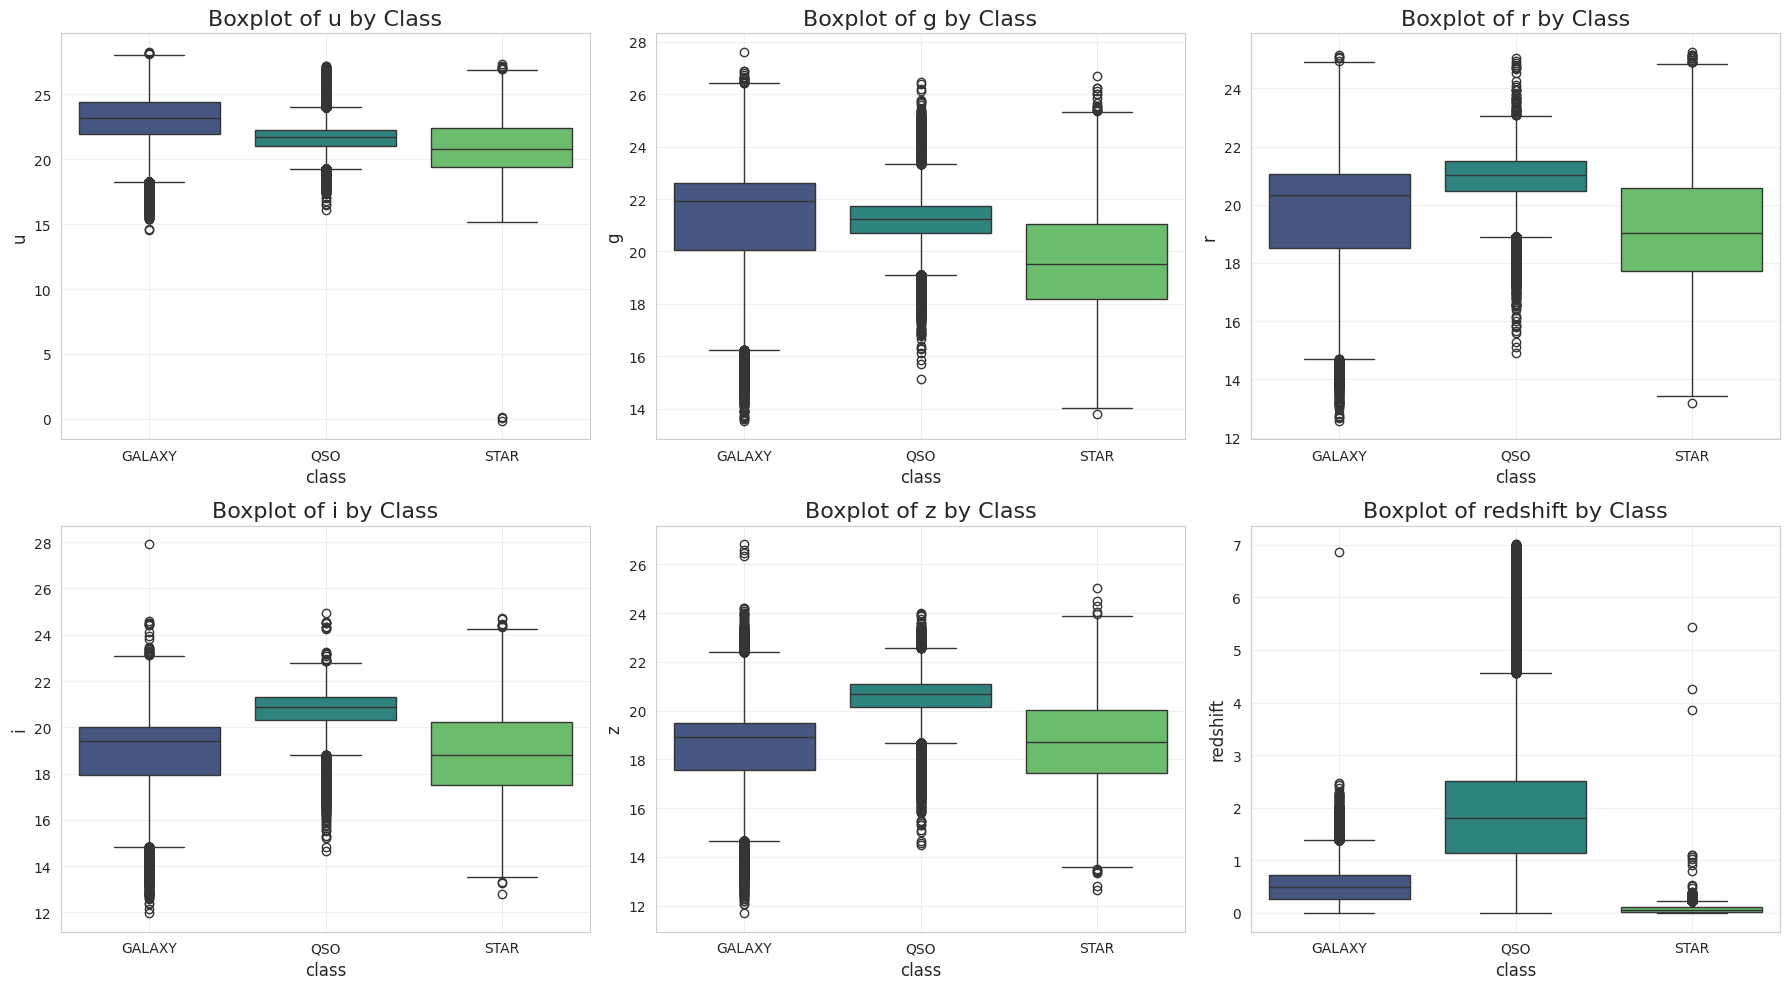

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(['u', 'g', 'r', 'i', 'z', 'redshift']):
    sns.boxplot(x='class', y=col, data=train_df, palette='viridis', ax=axes[idx])
    axes[idx].set_title(f'Boxplot of {col} by Class')
    axes[idx].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:** Quasars (red boxplots) show much wider variance in `u` magnitude and `redshift`, justifying why we need complex interactions.

## 5. 🛠️ Data Preprocessing & Feature Engineering

>- Now we apply our insights from EDA. We will:
 1. Drop irrelevant ID columns.
 2. Encode the target variable.
 3. Engineer Color Indices (`u-g`, `g-r`, `r-i`, `i-z`).
 4. Engineer "Locus Distances" (Euclidean distance to known stellar, QSO, and Galaxy centroids).
 5. Engineer Redshift interactions.

In [21]:
# Drop ID columns (they are just identifiers)
id_cols = ['id']
train_features = train_df.drop(columns=id_cols + ['class'])
test_features  = test_df.drop(columns=id_cols)


# Encode target
le = LabelEncoder()
y = le.fit_transform(train_df['class'])  # 0: Galaxy, 1: Star, 2: QSO
print("Classes:", le.classes_)

Classes: ['GALAXY' 'QSO' 'STAR']


In [22]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# --- START OF FULL PREPROCESSING CELL ---

# Define feature engineering functions (moved from later cells)
def add_color_features(df):
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']
    return df

def add_locus_distances(df):
    df['dist_stellar'] = np.sqrt((df['u_g'] - 0.8)**2 + (df['g_r'] - 0.4)**2)
    df['dist_qso'] = np.sqrt((df['u_g'] + 0.5)**2 + (df['g_r'] - 0.0)**2)
    df['dist_galaxy'] = np.sqrt((df['u_g'] - 1.2)**2 + (df['g_r'] - 0.6)**2)
    return df

def add_redshift_features(df):
    df['redshift_bin'] = pd.cut(df['redshift'],
                                bins=[-np.inf, 0.5, 1.0, 2.0, np.inf],
                                labels=[0, 1, 2, 3]).astype(int)
    df['redshift_x_u_g'] = df['redshift'] * df['u_g']
    return df

def add_advanced_features(df):
    df['stellar_locus_deviation'] = df['g_r'] - (0.4 * df['u_g'] + 0.08)
    df['magnitude_sum'] = df['u'] + df['g'] + df['r'] + df['i'] + df['z']
    df['magnitude_range'] = df[['u','g','r','i','z']].max(axis=1) - df[['u','g','r','i','z']].min(axis=1)
    df['u_g_squared'] = df['u_g'] ** 2
    df['g_r_squared'] = df['g_r'] ** 2
    df['redshift_x_mag_sum'] = df['redshift'] * df['magnitude_sum']
    return df

# 1. Drop ID columns
id_cols = ['id']
train_features = train_df.drop(columns=id_cols + ['class'])
test_features  = test_df.drop(columns=id_cols)

# 2. Encode target
le = LabelEncoder()
y = le.fit_transform(train_df['class'])
print("Classes:", le.classes_)

# 3. Feature engineering
train_features = add_color_features(train_features)
test_features  = add_color_features(test_features)

train_features = add_locus_distances(train_features)
test_features  = add_locus_distances(test_features)

train_features = add_redshift_features(train_features)
test_features  = add_redshift_features(test_features)

train_features = add_advanced_features(train_features)
test_features  = add_advanced_features(test_features)

# 4. DO NOT one‑hot encode 'spectral_type' and 'galaxy_population'.
#    Keep them as categorical (they will be passed to LightGBM & CatBoost natively).
X = train_features
X_test = test_features

# 5. Quick sanity check
print("✅ Preprocessing complete!")
print(f"Train shape: {X.shape}, Test shape: {X_test.shape}")
print("Categorical columns preserved:", ['spectral_type', 'galaxy_population'])

# --- END OF FULL PREPROCESSING CELL ---

Classes: ['GALAXY' 'QSO' 'STAR']
✅ Preprocessing complete!
Train shape: (577347, 25), Test shape: (247435, 25)
Categorical columns preserved: ['spectral_type', 'galaxy_population']


### 5.1 Standard Color Indices
- SDSS magnitudes (u,g,r,i,z) are used to compute colours: `u-g`, `g-r`, `r-i`, `i-z`.
- These are crucial for separating stellar types.


In [23]:
def add_color_features(df):
    # Magnitudes are in columns u, g, r, i, z
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']
    return df

train_features = add_color_features(train_features)
test_features  = add_color_features(test_features)

 We now have color indices. Next, we add the "secret sauce":
 1. **Locus Distances**: Euclidean distance to known Star, QSO, and Galaxy clusters in the (u-g, g-r) plane.
 2. **Redshift Enhancements**: Binning and interaction terms to help separate Quasars.

1. Locus Distances (Astronomical Domain Knowledge) ---
- These distances give the tree model explicit spatial awareness.
- Reference points derived from the Color-Color diagram we plotted earlier.

In [24]:
def add_color_features(df):
    # Magnitudes are in columns u, g, r, i, z
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']
    return df

train_features = add_color_features(train_features)
test_features  = add_color_features(test_features)

def add_locus_distances(df):
    # Distance to Stellar Locus (center at u-g=0.8, g-r=0.4)
    df['dist_stellar'] = np.sqrt((df['u_g'] - 0.8)**2 + (df['g_r'] - 0.4)**2)
    # Distance to QSO Locus (center at u-g=-0.5, g-r=0.0)
    df['dist_qso'] = np.sqrt((df['u_g'] + 0.5)**2 + (df['g_r'] - 0.0)**2)
    # Distance to Galaxy Locus (center at u-g=1.2, g-r=0.6)
    df['dist_galaxy'] = np.sqrt((df['u_g'] - 1.2)**2 + (df['g_r'] - 0.6)**2)
    return df

train_features = add_locus_distances(train_features)
test_features = add_locus_distances(test_features)

In [25]:
def advanced_feature_engineering(df):
    """Enhanced version with 20+ features instead of 10"""

    # Original features (KEEP THESE)
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']

    # NEW: Extended color combinations
    df['u_r'] = df['u'] - df['r']      # Broader span
    df['u_i'] = df['u'] - df['i']      # Very blue
    df['u_z'] = df['u'] - df['z']      # Total span
    df['g_i'] = df['g'] - df['i']
    df['g_z'] = df['g'] - df['z']
    df['r_z'] = df['r'] - df['z']

    # NEW: Magnitude statistics
    df['mag_span'] = df['u'] - df['z']
    df['mag_mid'] = (df['u'] + df['z']) / 2
    df['color_variance'] = df[['u_g', 'g_r', 'r_i', 'i_z']].var(axis=1)

    # NEW: Magnitude ratios
    df['u_g_ratio'] = df['u'] / (df['g'] + 1e-6)
    df['g_r_ratio'] = df['g'] / (df['r'] + 1e-6)

    # Original locus distances (KEEP THESE)
    df['dist_stellar'] = np.sqrt((df['u_g'] - 0.8)**2 + (df['g_r'] - 0.4)**2)
    df['dist_qso'] = np.sqrt((df['u_g'] + 0.5)**2 + (df['g_r'] - 0.0)**2)
    df['dist_galaxy'] = np.sqrt((df['u_g'] - 1.2)**2 + (df['g_r'] - 0.6)**2)

    # Original redshift features (KEEP THESE)
    df['redshift_bin'] = pd.cut(df['redshift'],
                                bins=[-np.inf, 0.5, 1.0, 2.0, np.inf],
                                labels=[0, 1, 2, 3]).astype(int)
    df['redshift_x_u_g'] = df['redshift'] * df['u_g']

    # NEW: Additional redshift features
    df['redshift_x_g_r'] = df['redshift'] * df['g_r']
    df['redshift_squared'] = df['redshift'] ** 2
    df['log_redshift'] = np.log1p(df['redshift'])

    # NEW: Multi-color interactions
    df['u_g_x_g_r'] = df['u_g'] * df['g_r']

    return df

In [26]:
# --- 2. Redshift Feature Engineering ---
# Quasars dominate high-redshift regions. Binning helps LightGBM find splits easily.
def add_redshift_features(df):
    # Create bins: 0-0.5, 0.5-1.0, 1.0-2.0, >2.0
    df['redshift_bin'] = pd.cut(df['redshift'],
                                bins=[-np.inf, 0.5, 1.0, 2.0, np.inf],
                                labels=[0, 1, 2, 3]).astype(int)
    # Interaction term: High redshift combined with blue color (u-g) heavily flags QSOs
    df['redshift_x_u_g'] = df['redshift'] * df['u_g']
    return df

train_features = add_redshift_features(train_features)
test_features = add_redshift_features(test_features)

print("✅ All features engineered!")
print(f"Final feature set: {train_features.columns.tolist()}")

✅ All features engineered!
Final feature set: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type', 'galaxy_population', 'u_g', 'g_r', 'r_i', 'i_z', 'dist_stellar', 'dist_qso', 'dist_galaxy', 'redshift_bin', 'redshift_x_u_g', 'stellar_locus_deviation', 'magnitude_sum', 'magnitude_range', 'u_g_squared', 'g_r_squared', 'redshift_x_mag_sum']


#### 📊 Quick Validation Check
- Let's visualize the `dist_stellar` and `dist_qso` features to confirm they actually separate the classes before we even train a model.

In [27]:
# --- ADVANCED FEATURE ENGINEERING (Insert here) ---
def add_advanced_features(df):
    # 1. Curvilinear distance to stellar locus (deviation from the line)
    df['stellar_locus_deviation'] = df['g_r'] - (0.4 * df['u_g'] + 0.08)

    # 2. Magnitude sum and range
    df['magnitude_sum'] = df['u'] + df['g'] + df['r'] + df['i'] + df['z']
    df['magnitude_range'] = df[['u','g','r','i','z']].max(axis=1) - df[['u','g','r','i','z']].min(axis=1)

    # 3. Polynomial interactions
    df['u_g_squared'] = df['u_g'] ** 2
    df['g_r_squared'] = df['g_r'] ** 2
    df['redshift_x_mag_sum'] = df['redshift'] * df['magnitude_sum']

    return df

train_features = add_advanced_features(train_features)
test_features = add_advanced_features(test_features)
print("✅ Advanced features added!")

✅ Advanced features added!


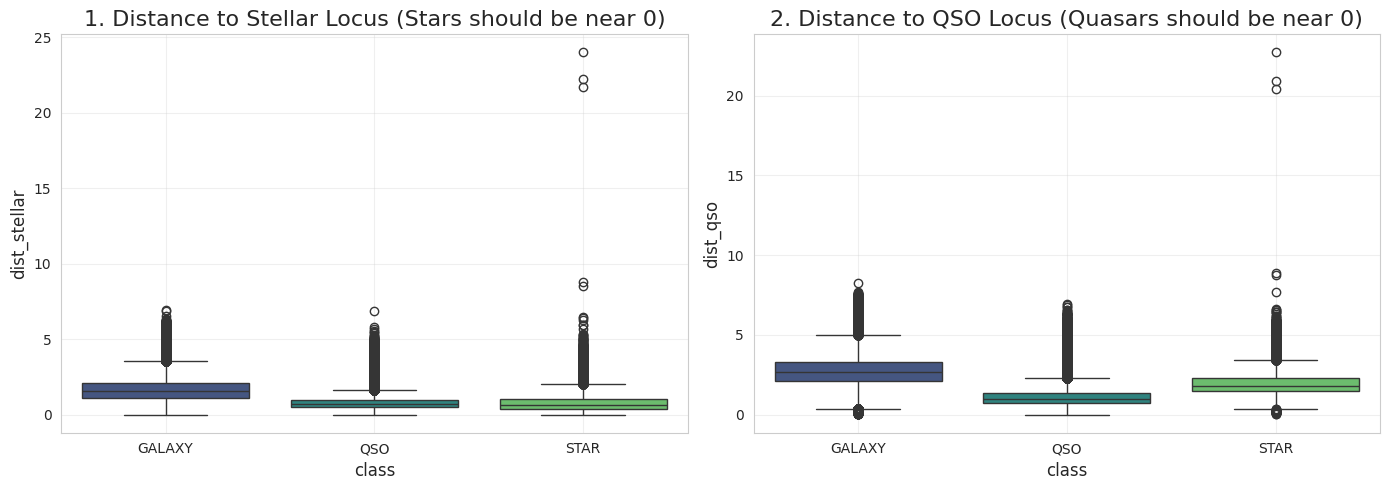

In [28]:
# Attach target back temporarily for plotting
temp_df = train_features.copy()
temp_df['class'] = train_df['class']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='class', y='dist_stellar', data=temp_df, palette='viridis', ax=axes[0])
axes[0].set_title('1. Distance to Stellar Locus (Stars should be near 0)')
axes[0].grid(True, alpha=0.3)

sns.boxplot(x='class', y='dist_qso', data=temp_df, palette='viridis', ax=axes[1])
axes[1].set_title('2. Distance to QSO Locus (Quasars should be near 0)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Great!** Notice how *Stars* have a very low `dist_stellar` and *QSOs* have a very low `dist_qso`. Our engineered features have successfully captured the physical separation we saw in the EDA.

## 6. 🧠 Modeling: Stratified K-Fold with LightGBM

- We will:
 1. Encode the target variable.
 2. Train a 5-Fold LightGBM.
 3. Use early stopping to prevent overfitting.
 4. Average predictions from 2 different random seeds for a robust ensemble.

In [29]:
import numpy as np
import pandas as pd
import os
import kagglehub
from sklearn.preprocessing import LabelEncoder

# --- Start of combined data loading, data preparation, and feature engineering ---

# NOTE: train_df and test_df are assumed to be loaded by previous cells (e.g., a16504b0).
#       Removed redundant data loading from this cell to avoid NameError.

# Define ID columns (from L551_SEIGMVB)
id_cols = ['id']

# Initial feature matrices from train_df and test_df
train_features = train_df.drop(columns=id_cols + ['class'])
test_features  = test_df.drop(columns=id_cols)

# Encode target variable y (from L551_SEIGMVB)
le = LabelEncoder()
y = le.fit_transform(train_df['class'])

# Feature Engineering Functions (consolidated from 7QZnT1FaHKDy, xvm6Gbr7Hz1C, -mfxeS-fQ46E, 5NE6O0KDc6Jg)
def add_color_features(df):
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']
    return df

def add_locus_distances(df):
    df['dist_stellar'] = np.sqrt((df['u_g'] - 0.8)**2 + (df['g_r'] - 0.4)**2)
    df['dist_qso'] = np.sqrt((df['u_g'] + 0.5)**2 + (df['g_r'] - 0.0)**2)
    df['dist_galaxy'] = np.sqrt((df['u_g'] - 1.2)**2 + (df['g_r'] - 0.6)**2)
    return df

def add_redshift_features(df):
    df['redshift_bin'] = pd.cut(df['redshift'],
                                bins=[-np.inf, 0.5, 1.0, 2.0, np.inf],
                                labels=[0, 1, 2, 3]).astype(int)
    df['redshift_x_u_g'] = df['redshift'] * df['u_g']
    return df

def add_advanced_features(df):
    df['stellar_locus_deviation'] = df['g_r'] - (0.4 * df['u_g'] + 0.08)
    df['magnitude_sum'] = df['u'] + df['g'] + df['r'] + df['i'] + df['z']
    df['magnitude_range'] = df[['u','g','r','i','z']].max(axis=1) - df[['u','g','r','i','z']].min(axis=1)
    df['u_g_squared'] = df['u_g'] ** 2
    df['g_r_squared'] = df['g_r'] ** 2
    df['redshift_x_mag_sum'] = df['redshift'] * df['magnitude_sum']
    return df

# Apply feature engineering steps in sequence
train_features = add_color_features(train_features)
test_features  = add_color_features(test_features)

train_features = add_locus_distances(train_features)
test_features = add_locus_distances(test_features)

train_features = add_redshift_features(train_features)
test_features = add_redshift_features(test_features)

train_features = add_advanced_features(train_features)
test_features = add_advanced_features(test_features)

print("✅ All features engineered!")

# --- End of combined data loading, data preparation, and feature engineering ---

# Prepare feature matrices (copy final engineered features to X and X_test for further processing)
X = train_features.copy()
X_test = test_features.copy()

print("X dtypes BEFORE one-hot encoding:")
print(X.dtypes[X.dtypes == 'object'])

# Dynamically identify categorical columns. Exclude 'spectral_type' and 'galaxy_population'
# as these will be handled as native categoricals by LightGBM/CatBoost.
al_object_cols = X.select_dtypes(include='object').columns.tolist()
cols_to_exclude_from_ohe = ['spectral_type', 'galaxy_population']
categorical_cols_for_ohe = [col for col in al_object_cols if col not in cols_to_exclude_from_ohe]

if categorical_cols_for_ohe:
    print(f"Found categorical columns for one-hot encoding: {categorical_cols_for_ohe}")
    X = pd.get_dummies(X, columns=categorical_cols_for_ohe, drop_first=True)
    X_test = pd.get_dummies(X_test, columns=categorical_cols_for_ohe, drop_first=True)
else:
    print("No additional object columns found in X for one-hot encoding.")

# Align columns - very important for consistent feature sets between train and test
# This handles cases where one set might not have all categories present in the other
train_cols = X.columns
test_cols = X_test.columns

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test[c] = 0

missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    X[c] = 0

X_test = X_test[train_cols]

print(f"Training shape: {X.shape}")
print(f"Test shape: {X_test.shape}")
print("X dtypes AFTER one-hot encoding:")
print(X.dtypes[X.dtypes == 'object'])

✅ All features engineered!
X dtypes BEFORE one-hot encoding:
spectral_type        object
galaxy_population    object
dtype: object
No additional object columns found in X for one-hot encoding.
Training shape: (577347, 25)
Test shape: (247435, 25)
X dtypes AFTER one-hot encoding:
spectral_type        object
galaxy_population    object
dtype: object


In [30]:
%%time
# LightGBM Parameters (Tuned for this dataset)
lgb_params = {
    'objective': 'multiclass',
    'num_class': 3,
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 127,
    'learning_rate': 0.08,
    'max_depth': 9,
    'feature_fraction': 0.85,
    'bagging_fraction': 0.85,
    'bagging_freq': 5,
    'min_data_in_leaf': 20,
    'lambda_l1': 0.5,
    'lambda_l2': 0.5,
    'categorical_feature': ['spectral_type', 'galaxy_population'],   # <-- add this
    'seed': 42,   # will be overwritten per seed in the loop
    'verbosity': -1,
    'n_jobs': -1,
}

# Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Seeds for ensemble
seeds = [42, 123, 456, 789]

# Storage for predictions
test_predictions = []
oof_scores = []

CPU times: user 34 µs, sys: 0 ns, total: 34 µs
Wall time: 38.4 µs


## 7. Ensemble Averaging & Final Validation

In [32]:
%%time
# ==================== CORRECTED TRAINING LOOP ====================

import torch
gpu_available = torch.cuda.is_available()

# Ensure categorical columns are of type 'category'
cat_cols = ['spectral_type', 'galaxy_population']
for col in cat_cols:
    X[col] = X[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# LightGBM Parameters
lgb_params = {
    'objective': 'multiclass',
    'num_class': 3,
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 127,
    'learning_rate': 0.08,
    'max_depth': 9,
    'feature_fraction': 0.85,
    'bagging_fraction': 0.85,
    'bagging_freq': 5,
    'min_data_in_leaf': 20,
    'lambda_l1': 0.5,
    'lambda_l2': 0.5,
    'categorical_feature': cat_cols,
    'seed': 42,
    'verbosity': -1,
    'n_jobs': -1,
}

# XGBoost Parameters – with correct GPU settings
xgb_params = {
    'objective': 'multi:softprob',
    'num_class': 3,
    'eval_metric': 'mlogloss',
    'eta': 0.05,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 1,
    'gamma': 0.1,
    'n_jobs': -1,
    'use_label_encoder': False,
    'enable_categorical': True,
    'tree_method': 'hist',          # <-- always 'hist' for categorical + GPU
}
# If GPU is available, add device='cuda'
if gpu_available:
    xgb_params['device'] = 'cuda'   # <-- enables GPU for XGBoost
    print("XGBoost will use GPU")

# CatBoost Parameters (cat_features passed in fit)
cat_params = {
    'iterations': 700,
    'learning_rate': 0.05,
    'depth': 7,
    'loss_function': 'MultiClass',
    'eval_metric': 'MultiClass',
    'verbose': 0,
    'l2_leaf_reg': 3,
}
if gpu_available:
    cat_params['task_type'] = 'GPU'
    print("CatBoost will use GPU")

# Stratified K‑Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Seeds – you can reduce to [42, 123] for faster runs
seeds = [42, 123, 456, 789]

# Storage for OOF and test predictions
lgb_oof_preds = np.zeros((X.shape[0], 3))
xgb_oof_preds = np.zeros((X.shape[0], 3))
cb_oof_preds  = np.zeros((X.shape[0], 3))

lgb_test_preds = []
xgb_test_preds = []
cb_test_preds  = []

oof_scores = []

NUM_ROUNDS = 700   # reduce to 300 for quicker tests

for seed in seeds:
    print(f"\nʙ Training ensemble with seed: {seed}")

    lgb_params['seed'] = seed
    xgb_params['random_state'] = seed
    if gpu_available:
        cat_params['random_seed'] = seed

    oof_lgb_seed = np.zeros((X.shape[0], 3))
    oof_xgb_seed = np.zeros((X.shape[0], 3))
    oof_cb_seed  = np.zeros((X.shape[0], 3))

    test_lgb_seed = np.zeros((X_test.shape[0], 3))
    test_xgb_seed = np.zeros((X_test.shape[0], 3))
    test_cb_seed  = np.zeros((X_test.shape[0], 3))

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        print(f"  Fold {fold_idx+1}/5", end=" -> ")

        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # --- LightGBM ---
        dtrain = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_cols)
        dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain, categorical_feature=cat_cols)
        lgb_model = lgb.train(
            lgb_params,
            dtrain,
            valid_sets=[dtrain, dval],
            num_boost_round=NUM_ROUNDS,
            callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
        )
        oof_lgb_seed[val_idx] = lgb_model.predict(X_val, num_iteration=lgb_model.best_iteration)
        test_lgb_seed += lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration) / skf.n_splits

        # --- XGBoost ---
        xgb_model = XGBClassifier(
            **xgb_params,
            n_estimators=NUM_ROUNDS,
            early_stopping_rounds=50
        )
        xgb_model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )
        oof_xgb_seed[val_idx] = xgb_model.predict_proba(X_val)
        test_xgb_seed += xgb_model.predict_proba(X_test) / skf.n_splits

        # --- CatBoost ---
        cat_model = CatBoostClassifier(**cat_params)
        cat_model.fit(
            X_train, y_train,
            cat_features=cat_cols,
            eval_set=[(X_val, y_val)],
            early_stopping_rounds=50,
            verbose=False
        )
        oof_cb_seed[val_idx] = cat_model.predict_proba(X_val)
        test_cb_seed += cat_model.predict_proba(X_test) / skf.n_splits

        # Print fold accuracy
        lgb_acc = accuracy_score(y_val, np.argmax(oof_lgb_seed[val_idx], axis=1))
        xgb_acc = accuracy_score(y_val, np.argmax(oof_xgb_seed[val_idx], axis=1))
        cb_acc  = accuracy_score(y_val, np.argmax(oof_cb_seed[val_idx], axis=1))
        print(f"LGB: {lgb_acc:.4f}, XGB: {xgb_acc:.4f}, CB: {cb_acc:.4f}")

    # Accumulate OOF (average over seeds)
    lgb_oof_preds += oof_lgb_seed / len(seeds)
    xgb_oof_preds += oof_xgb_seed / len(seeds)
    cb_oof_preds  += oof_cb_seed  / len(seeds)

    lgb_test_preds.append(test_lgb_seed)
    xgb_test_preds.append(test_xgb_seed)
    cb_test_preds.append(test_cb_seed)

    seed_oof_acc = accuracy_score(y, np.argmax(oof_lgb_seed, axis=1))
    oof_scores.append(seed_oof_acc)
    print(f"✅ Seed {seed} – LightGBM OOF Acc: {seed_oof_acc:.4f}")

print("\n✅ Optimized multi‑model ensemble training complete!")

XGBoost will use GPU
CatBoost will use GPU

ʙ Training ensemble with seed: 42
  Fold 1/5 -> Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[240]	training's multi_logloss: 0.0526521	valid_1's multi_logloss: 0.089248
LGB: 0.9680, XGB: 0.9672, CB: 0.9641
  Fold 2/5 -> Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[273]	training's multi_logloss: 0.0486962	valid_1's multi_logloss: 0.0900667
LGB: 0.9679, XGB: 0.9678, CB: 0.9640
  Fold 3/5 -> Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[271]	training's multi_logloss: 0.0492047	valid_1's multi_logloss: 0.0917752
LGB: 0.9672, XGB: 0.9660, CB: 0.9628
  Fold 4/5 -> Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[233]	training's multi_logloss: 0.0535913	valid_1's multi_logloss: 0.0905837
LGB: 0.9676, XGB: 0.9673, CB: 0.9638
  Fold 5/5 -> Training unti

In [33]:
  # ========== 1. Compute individual OOF accuracies ==========
lgb_acc = accuracy_score(y, np.argmax(lgb_oof_preds, axis=1))
xgb_acc = accuracy_score(y, np.argmax(xgb_oof_preds, axis=1))
cb_acc  = accuracy_score(y, np.argmax(cb_oof_preds, axis=1))

print("Individual OOF Accuracies:")
print(f"  LightGBM: {lgb_acc:.4f}")
print(f"  XGBoost:  {xgb_acc:.4f}")
print(f"  CatBoost: {cb_acc:.4f}")

# ========== 2. Compute ensemble weights ==========
weights = np.array([lgb_acc, xgb_acc, cb_acc])
weights = weights / weights.sum()

print("\nEnsemble weights (proportional to OOF accuracy):")
print(f"  LightGBM: {weights[0]:.4f}")
print(f"  XGBoost:  {weights[1]:.4f}")
print(f"  CatBoost: {weights[2]:.4f}")

# ========== 3. Weighted average of test predictions ==========
# Check that the prediction lists are not empty and have the expected shape
print("\nChecking prediction lists:")
print(f"  lgb_test_preds: {len(lgb_test_preds)} seeds, shape {lgb_test_preds[0].shape if lgb_test_preds else 'empty'}")
print(f"  xgb_test_preds: {len(xgb_test_preds)} seeds, shape {xgb_test_preds[0].shape if xgb_test_preds else 'empty'}")
print(f"  cb_test_preds:  {len(cb_test_preds)} seeds, shape {cb_test_preds[0].shape if cb_test_preds else 'empty'}")

# Weighted ensemble predictions
final_test_preds = (np.mean(lgb_test_preds, axis=0) * weights[0] +
                    np.mean(xgb_test_preds, axis=0) * weights[1] +
                    np.mean(cb_test_preds, axis=0) * weights[2])

print(f"\nFinal test predictions shape: {final_test_preds.shape}")  # Should be (n_test, 3)

Individual OOF Accuracies:
  LightGBM: 0.9680
  XGBoost:  0.9670
  CatBoost: 0.9637

Ensemble weights (proportional to OOF accuracy):
  LightGBM: 0.3339
  XGBoost:  0.3336
  CatBoost: 0.3325

Checking prediction lists:
  lgb_test_preds: 4 seeds, shape (247435, 3)
  xgb_test_preds: 4 seeds, shape (247435, 3)
  cb_test_preds:  4 seeds, shape (247435, 3)

Final test predictions shape: (247435, 3)


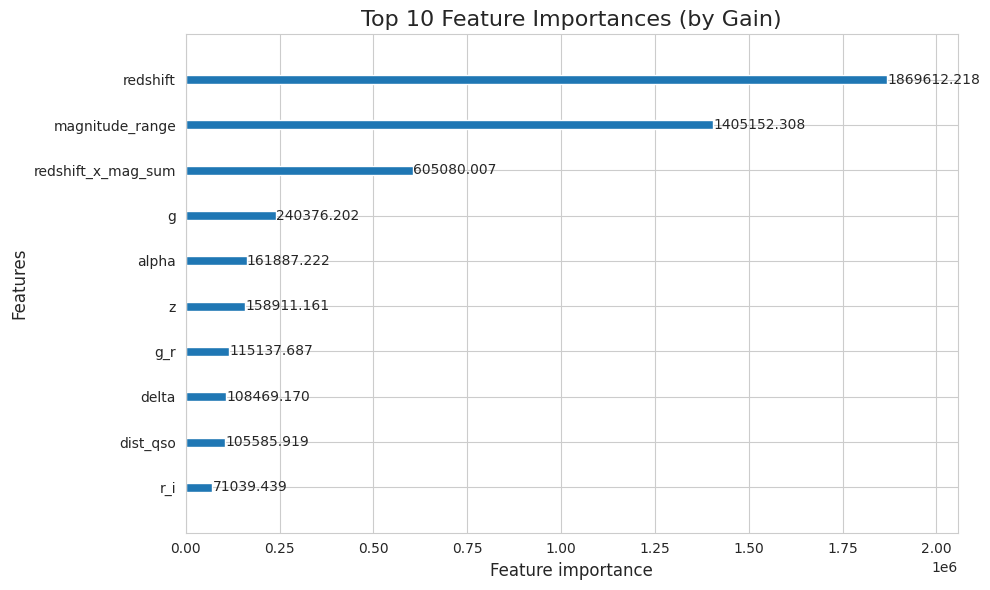

In [35]:
import lightgbm as lgb
import matplotlib.pyplot as plt

# Re-train a quick LightGBM on the full encoded data to visualize feature importance
full_model = lgb.train(
    lgb_params,  # use the same parameters
    lgb.Dataset(X, label=y),
    num_boost_round=200
)
lgb.plot_importance(full_model, max_num_features=10, figsize=(10,6), importance_type='gain')
plt.title('Top 10 Feature Importances (by Gain)')
plt.tight_layout()
plt.show()

## 8. 📄 Generate Submission File

In [36]:
# ========== 4. Generate submission ==========
pred_class_indices = np.argmax(final_test_preds, axis=1)
submission_labels = le.inverse_transform(pred_class_indices)

submission = submission_df.copy()
submission['class'] = submission_labels
submission.to_csv('submission.csv', index=False)

print("\n✅ Submission file 'submission.csv' created successfully!")
print(submission.head(10))
print("\n🚀 You can now submit 'submission.csv' to Kaggle!")


✅ Submission file 'submission.csv' created successfully!
       id   class
0  577347  GALAXY
1  577348  GALAXY
2  577349  GALAXY
3  577350    STAR
4  577351  GALAXY
5  577352  GALAXY
6  577353  GALAXY
7  577354    STAR
8  577355  GALAXY
9  577356  GALAXY

🚀 You can now submit 'submission.csv' to Kaggle!


👍 **If this notebook helped you achieve a solid score, please consider upvoting!**  
Your support keeps me motivated to share more high-quality kernels. Happy coding! 🚀